# Import Required Libraries
Import pandas and other necessary libraries for data manipulation and analysis.

In [1]:
import pandas as pd  # Import pandas for data manipulation and analysis
import numpy as np  # Import numpy for numerical operations
import matplotlib.pyplot as plt  # Import matplotlib for data visualization
import torch
import os
from ODE_BINN_fcts_nodgdu import *

In [2]:
def set_pubstyle(fontsize=10, font_family='serif', usetex=False):
    plt.rcParams.update({
        "font.size": fontsize,
        "font.family": font_family,
        "axes.labelsize": fontsize,
        "axes.titlesize": fontsize + 1,
        "legend.fontsize": fontsize - 1,
        "xtick.labelsize": fontsize - 1,
        "ytick.labelsize": fontsize - 1,
        "figure.titlesize": fontsize + 2,
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "lines.linewidth": 1.6,
        "axes.linewidth": 0.8,
        "grid.alpha": 0.2,
        "figure.figsize": (6.92, 4.2),
    })
    if usetex:
        plt.rcParams.update({"text.usetex": True})

# Call once globally for consistent style
set_pubstyle(fontsize=10, font_family='serif', usetex=False)

# Load an Excel File
Use pandas' read_excel() function to load an Excel file into a DataFrame.

In [3]:
# Load an Excel file into a DataFrame
file_path = 'CoralReef-Data.xlsx'  # Specify the path to the Excel file
df = pd.read_excel(file_path)  # Load the Excel file into a DataFrame

# Display the Data
Display the first few rows of the DataFrame using the head() method.

In [4]:
# Display the first few rows of the DataFrame using the head() method
df.head()  # Display the first 5 rows of the DataFrame

,Time,Site 1,Site 3
0,0,2.352255,0.133333
1,769,4.396074,4.115504
2,1140,8.434146,10.824486
3,1488,22.250794,26.299884
4,1876,38.900000,41.622581


# Perform Basic Data Analysis
Perform basic analysis such as checking for null values, data types, and descriptive statistics.

In [5]:
# Check for null values in the DataFrame
null_values = df.isnull().sum()  # Count the number of null values in each column
print("Null values in each column:")
print(null_values)

# Check the data types of each column
data_types = df.dtypes  # Get the data types of each column
print("\nData types of each column:")
print(data_types)

# Generate descriptive statistics for the DataFrame
descriptive_stats = df.describe()  # Get descriptive statistics for numerical columns
print("\nDescriptive statistics:")
print(descriptive_stats)

Null values in each column:
Time      0
Site 1    0
Site 3    0
dtype: int64

Data types of each column:
Time        int64
Site 1    float64
Site 3    float64
dtype: object

Descriptive statistics:
              Time     Site 1     Site 3
count    11.000000  11.000000  11.000000
mean   2169.000000  46.365189  40.721932
std    1250.484626  31.912604  26.255941
min       0.000000   2.352255   0.133333
25%    1314.000000  15.342470  18.562185
50%    2233.000000  59.048030  51.748649
75%    3051.000000  71.807036  59.635342
max    4028.000000  82.292308  72.162814


In [6]:
# Load the data (already loaded in CR_analysis as `df`)
time = df['Time'].values.astype(np.float32)
site_1 = df['Site 1'].values.astype(np.float32)
site_3 = df['Site 3'].values.astype(np.float32)

# Normalize the data (if needed)
time = (time - time.min()) / (time.max() - time.min())
site_1 = (site_1 - site_1.min()) / (site_1.max() - site_1.min())
site_3 = (site_3 - site_3.min()) / (site_3.max() - site_3.min())

datasets = {
    "Site 1": {"t": time, "C_list": [site_1]},
    "Site 3": {"t": time, "C_list": [site_3]},
}

# Directory to save results
save_dir = "./BINN_runs/CR_analysis"
os.makedirs(save_dir, exist_ok=True)

In [8]:
# Train BINNs for each site
ensembles = {}
for site, dataset in datasets.items():
    site_save_dir = os.path.join(save_dir, site.replace(" ", "_"))
    os.makedirs(site_save_dir, exist_ok=True)
    
    # Train BINNs
    ensemble = BINNs.trainBINN_ODE_g_multiRep_noise(
        Numrep=10, 
        device="cuda" if torch.cuda.is_available() else "cpu",
        dataset=dataset,
        save_dir=site_save_dir,
        t_min=float(time.min()),
        t_max=float(time.max()),
        n_epochs=4000,
        N_PDE=256,
        batch_size=64,
        learning_rate=1e-3,
        u_num_layers=3,
        u_hidden_units=64,
        u_activation_fn=nn.Tanh(),
        G_num_layers=3,
        G_hidden_units=64,
        G_activation_fn=nn.Tanh(),
        u_weight=1.0,
        ode_weight=1.0,
        ic_weight=0.0,
        bio_weight=1.0,
        train_ratio=0.6,
        val_ratio=0.2,
        band_mode="sd",
        # seed=123,
        noise_mode="power",
        use_nll=True,
        data_sort="random",
    )
    ensembles[site] = ensemble


In [9]:
def plot_binn_results_2x3(ensembles, save_dir):
    """
    Plot BINN results for multiple sites in a 2x3 grid.

    Parameters:
        ensembles : dict
            Dict like {"Site 1": ensemble1, "Site 2": ensemble2}
        save_dir : str
            Directory to save the plot
    """
    sites = list(ensembles.keys())
    n_sites = len(sites)

    assert n_sites == 2, "This function is set up for exactly 2 sites (2x3 layout)."

    fig, axes = plt.subplots(2, 3, figsize=(6.92, 4.2), sharex='col')

    for i, site in enumerate(sites):
        ensemble = ensembles[site]

        # Extract
        t = ensemble["t_full"]
        C_true = ensemble["C_reps"][0]
        C_pred = ensemble["C_full_mean"]
        C_pred_low = ensemble["C_full_low"]
        C_pred_up = ensemble["C_full_up"]

        g_mean = ensemble["g_mean"]
        g_low = ensemble["g_low"]
        g_up = ensemble["g_up"]
        C_grid = ensemble["C_grid"]

        sigma_mean = ensemble["sigma_full_mean"]
        sigma_low = ensemble["sigma_full_low"]
        sigma_up = ensemble["sigma_full_up"]

        # ---- Column 1: dynamics ----
        ax = axes[i, 0]
        ax.plot(t, C_true, marker="o", linestyle="None", label="Data", ms=4)
        ax.plot(t, C_pred, linestyle="-", color="C0", lw=2, label="Mean")
        ax.fill_between(t, C_pred_low, C_pred_up, color="C0", alpha=0.2)

        ax.set_ylabel(f"{site}\n$u$")
        if i == n_sites - 1:
            ax.set_xlabel("Time")

            # ax.set_title(r"$u$")

        # ---- Column 2: g(u) ----
        ax = axes[i, 1]
        ax.plot(C_grid, g_mean, color="C1", lw=2)
        ax.fill_between(C_grid, g_low, g_up, color="C1", alpha=0.2)

        if i == n_sites - 1:
            ax.set_xlabel("$u$")
        ax.set_ylabel(r"$g(u)$")

        # ---- Column 3: noise ----
        ax = axes[i, 2]
        ax.plot(t, sigma_mean, color="C2", lw=2)
        ax.fill_between(t, sigma_low, sigma_up, color="C2", alpha=0.2)

        if i == n_sites - 1:
            ax.set_xlabel("Time")
        ax.set_ylabel(r"$\sigma$")

       # ---- Add learned parameter text ----
        sigma_base_runs = ensemble.get("sigma_base_runs", None)
        beta_runs = ensemble.get("beta_runs", None)
        noise_mode = ensemble.get("noise_mode", None)

        text_lines = []

        if sigma_base_runs is not None:
            sigma_base_mean = np.nanmean(sigma_base_runs)
            text_lines.append(rf"$\sigma_0 = {sigma_base_mean:.3f}$")

        if beta_runs is not None:
            beta_mean = np.nanmean(beta_runs)
            text_lines.append(rf"$\alpha = {beta_mean:.3f}$")

        if text_lines:
            ax.text(
                0.97, 0.97,
                "\n".join(text_lines),
                transform=ax.transAxes,
                ha="right",
                va="bottom",
                fontsize=8,
                bbox=dict(
                    boxstyle="round,pad=0.3",
                    facecolor="white",
                    alpha=0.85,
                    edgecolor="none"
                )
            )

    # Clean styling
    for ax in axes.flat:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(True, alpha=0.2)

    # One legend only (top-left panel)
    axes[0, 0].legend(frameon=False)

    plt.tight_layout()

    plot_path = os.path.join(save_dir, "BINN_results_2x3.png")
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()

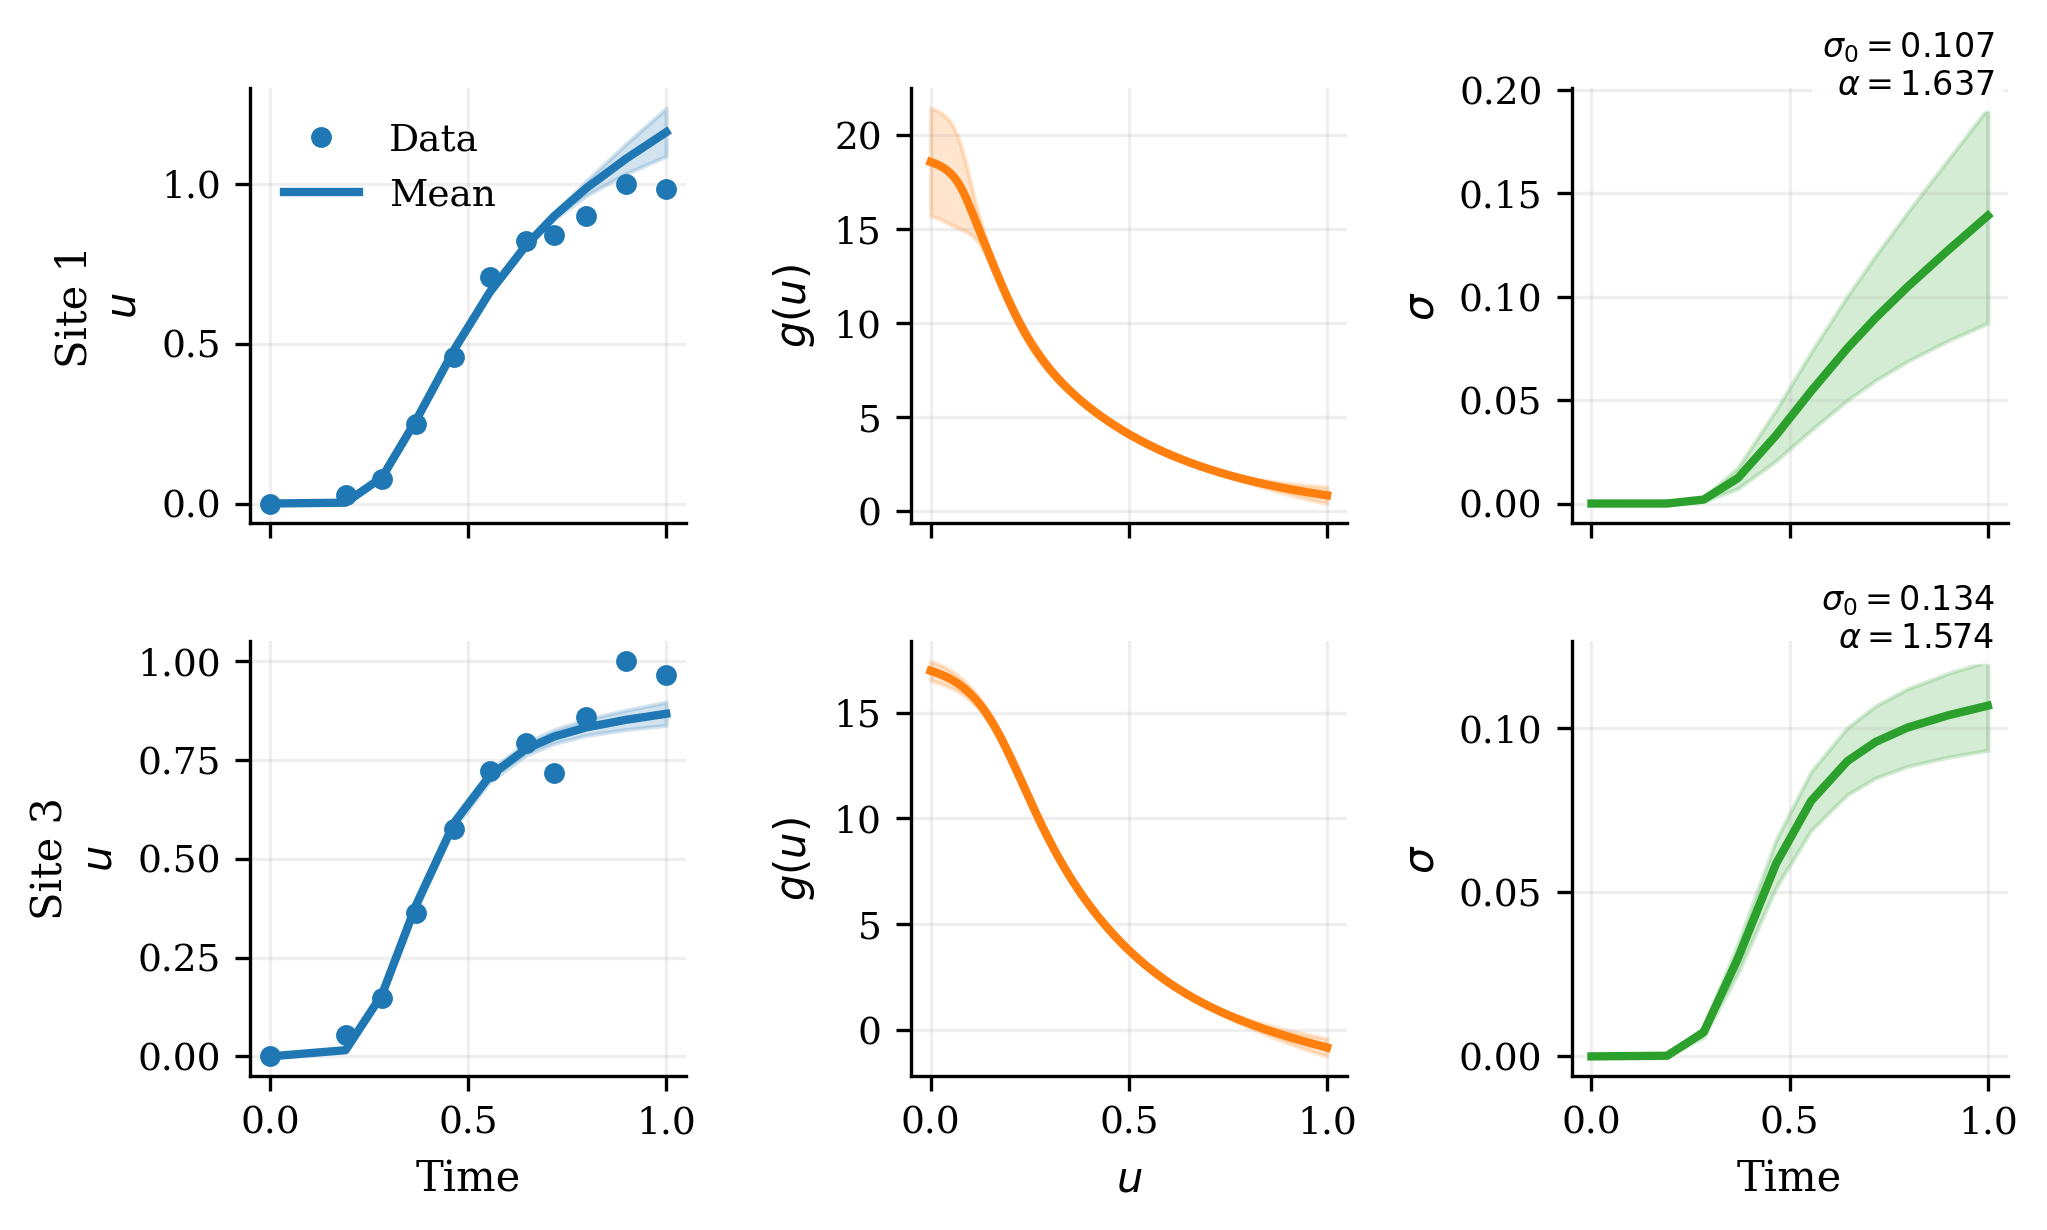

In [10]:
plot_binn_results_2x3(ensembles, save_dir)